Объем продаж на следующий месяц

In [2]:
import pandas as pd

data = {
    "date": pd.date_range(start='2022-01-01', periods=24, freq='ME'),
    "sales": [305, 356, 378, 399, 450, 478, 505, 512, 490, 475, 460, 455,
              480, 520, 540, 580, 600, 630, 650, 670, 690, 710, 700, 680]
}

df = pd.DataFrame(data)
df.set_index('date', inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_7608\1455375227.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


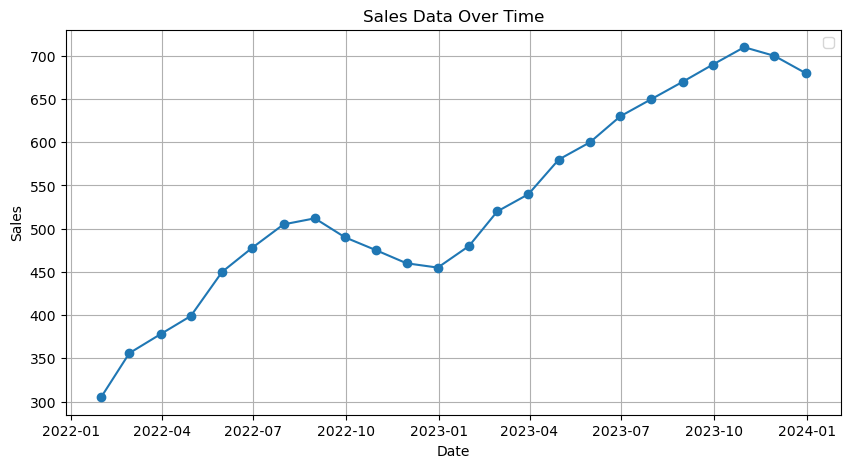

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['sales'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Data Over Time')
plt.legend()
plt.grid()
plt.show()

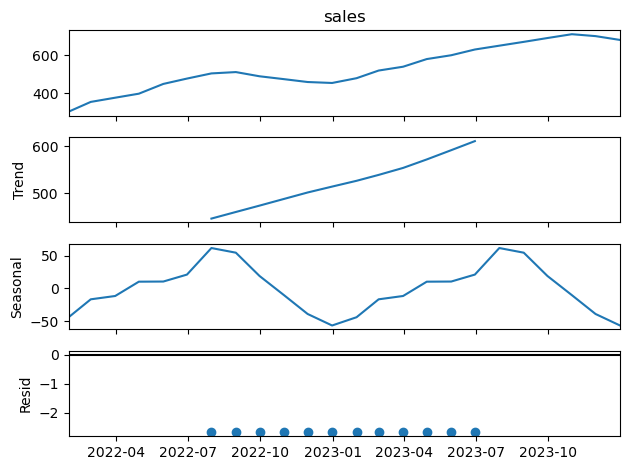

In [ ]:
# разделим временной ряд на три компоненты: тренд, сезонность и остатки (шум)
# тренд - показывает долгосрочный рост
# сезонность - показывает повторяющиеся паттерны (колебания) в течение года
# шум - показывает случайные колебания, которые не объясняются трендом или сезонностью

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['sales'], model='additive', period=12)

result.plot()
plt.show()

In [ ]:
# строим модель прогноза

from statsmodels.tsa.statespace.sarimax import SARIMAX # подходит для сезонных временных рядов

model = SARIMAX(df['sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model = SARIMAX(df['sales'], order=(1, 1, 1), seasonal_order=(1, 0, 0, 12))
model_fit = model.fit(disp=False)

# steps = 1 означает, что мы хотим сделать прогноз на один шаг вперед (т.е. на следующий месяц)
forecast = model_fit.forecast(steps=1)
print(f'прогноз продаж на след месяц: {forecast.values[0]:.2f}')

прогноз продаж на след месяц: 668.75


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


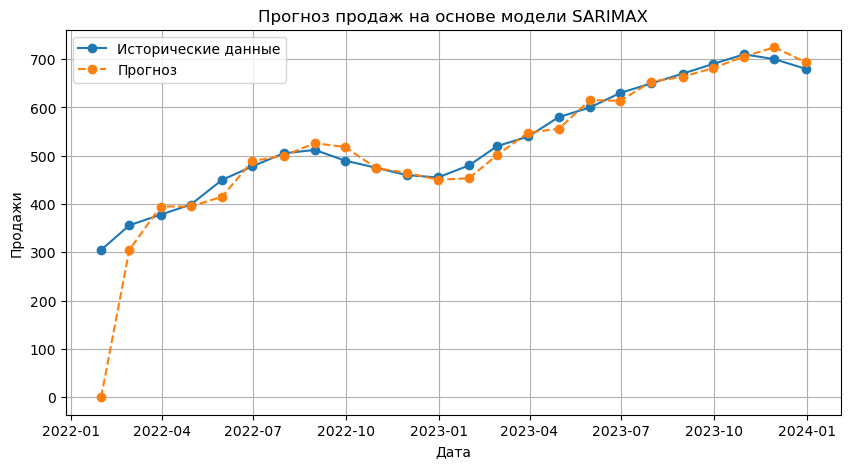

In [13]:
# визуализируем прогноз вместе с историческими данными
# чтобы проанализировать как прогнозированные значения вписываются в общую динамику

df['forecast'] = model_fit.predict(start=0, end=len(df)-1, dynamic=False)
figure = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=1, freq='ME')
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['sales'], label='Исторические данные', marker='o')
plt.plot(df.index, df['forecast'], label='Прогноз', marker='o', linestyle='--')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.title('Прогноз продаж на основе модели SARIMAX')
plt.legend()
plt.grid()
plt.show()